In [79]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Gpu Available:", torch.cuda.is_available())
print("Cuda Device Count:", torch.cuda.device_count())
print("Current Device:", torch.cuda.current_device())

Gpu Available: True
Cuda Device Count: 1
Current Device: 0


In [80]:
weight = 30000      # salary increase per year
bias = 15000       # starting salary

start = 1
end = 21           # 1 to 20 years
step = 1

X = torch.arange(start, end, step).unsqueeze(-1)
noise = torch.randn(len(X), 1) * 2000
y = weight * X + bias + noise

print(X[:5])
print(y[:5])

tensor([[1],
        [2],
        [3],
        [4],
        [5]])
tensor([[ 48853.8320],
        [ 77974.5703],
        [106801.4375],
        [130788.9609],
        [163483.7344]])


In [81]:
# data split

split_percentage = int(0.8 * len(X))
x_train_dataset , y_train_dataset = X[:split_percentage], y[:split_percentage]
x_test_dataset , y_test_dataset = X[split_percentage:], y[split_percentage:]

len(x_train_dataset) , len(y_train_dataset) , len(x_test_dataset) , len(y_test_dataset)



(16, 16, 4, 4)

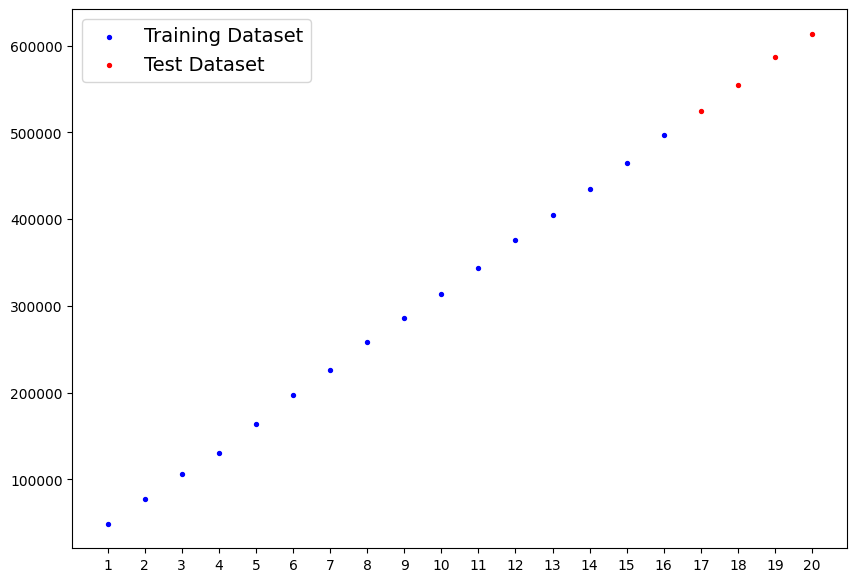

In [82]:
def plot_data(
    train_x=x_train_dataset,
    train_y=y_train_dataset,
    test_x=x_test_dataset,
    test_y=y_test_dataset,
    predictions=None
):
  plt.figure(figsize=(10,7))
  plt.xticks(range(1, 23))  
  
  plt.scatter(train_x,train_y,s=8,c="b",label="Training Dataset")  
  plt.scatter(test_x,test_y,s=8,c="r",label="Test Dataset")  

  if predictions is not None:
      plt.scatter(test_x,predictions,s=12,c="g",label="Predictions")  
  
  plt.legend(prop={"size":14})


plot_data()

In [83]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))
        
    def forward(self, x: torch.Tensor):
        return self.weights * x  + self.bias

In [84]:
model = LinearRegression()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([-0.7658]), 'bias': tensor([-0.7506])})
[Parameter containing:
tensor([-0.7658], requires_grad=True), Parameter containing:
tensor([-0.7506], requires_grad=True)]


tensor([[-13.7699],
        [-14.5357],
        [-15.3016],
        [-16.0674]])


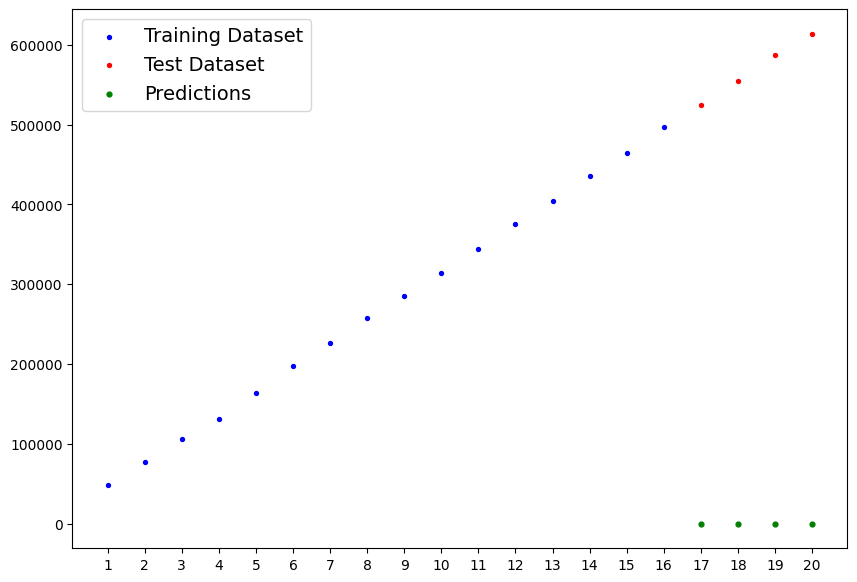

In [85]:
torch.manual_seed(42)

with torch.inference_mode():
    predictions=model(x_test_dataset)
    
    
print(predictions)
plot_data(predictions=predictions)

In [86]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=1)

In [87]:
epochs = 25000

for epoch in range(epochs):
    model.train()

    model_predicton = model(x_train_dataset)
    loss = loss_fn(model_predicton, y_train_dataset)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")    


Epoch: 0 | Loss: 270613.125
Epoch: 1000 | Loss: 197363.09375
Epoch: 2000 | Loss: 124113.09375
Epoch: 3000 | Loss: 50863.10546875
Epoch: 4000 | Loss: 4948.57421875
Epoch: 5000 | Loss: 4800.453125
Epoch: 6000 | Loss: 4652.453125
Epoch: 7000 | Loss: 4504.328125
Epoch: 8000 | Loss: 4356.328125
Epoch: 9000 | Loss: 4208.203125
Epoch: 10000 | Loss: 4060.203369140625
Epoch: 11000 | Loss: 3912.203369140625
Epoch: 12000 | Loss: 3764.078369140625
Epoch: 13000 | Loss: 3616.078369140625
Epoch: 14000 | Loss: 3467.953369140625
Epoch: 15000 | Loss: 3319.953369140625
Epoch: 16000 | Loss: 3173.609619140625
Epoch: 17000 | Loss: 3053.230712890625
Epoch: 18000 | Loss: 2979.880126953125
Epoch: 19000 | Loss: 2921.442626953125
Epoch: 20000 | Loss: 2863.005126953125
Epoch: 21000 | Loss: 2804.567626953125
Epoch: 22000 | Loss: 2746.130126953125
Epoch: 23000 | Loss: 2687.692626953125
Epoch: 24000 | Loss: 2629.255126953125


tensor([[527089.3750],
        [557466.5000],
        [587843.5625],
        [618220.6875]])


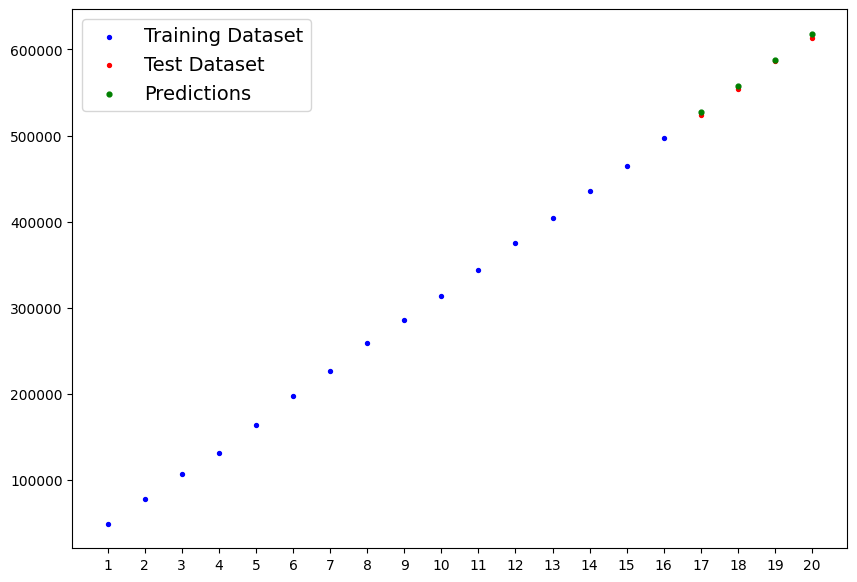

In [88]:
with torch.inference_mode():
    y_preds = model(x_test_dataset)

print(y_preds)
plot_data(predictions=y_preds)

In [89]:
print(model.state_dict())

OrderedDict({'weights': tensor([30377.1094]), 'bias': tensor([10678.5000])})
